<a href="https://colab.research.google.com/github/RohitRajgoli/RohitRajgoli.github.io/blob/main/Projects/Python%3AML%3ATableau/US_credit_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
sns.set(style = 'whitegrid')

In [32]:
df = pd.read_csv('/content/us_credit_dataset.csv')

In [33]:
df.head()

,Customer_ID,Age,Gender,State,Education_Level,Annual_Income,Credit_Limit,Avg_Monthly_Spend,Num_Late_Payments,Credit_Utilization_Rate,Employment_Type,Credit_Score
0,USCUST100000,59,Female,Illinois,Bachelor’s Degree,66596,16202,1512,2,1.12,Full-Time,400
1,USCUST100001,72,Female,California,Associate Degree,96799,19004,2109,1,1.33,Retired,397
2,USCUST100002,49,Male,Michigan,Master’s Degree,58504,20415,1133,1,0.67,Full-Time,558
3,USCUST100003,35,Female,Georgia,High School,43591,11057,1280,1,1.39,Part-Time,326
4,USCUST100004,63,Female,California,Master’s Degree,80477,24745,1883,3,0.91,Full-Time,446


Text(0, 0.5, 'No. of customers')

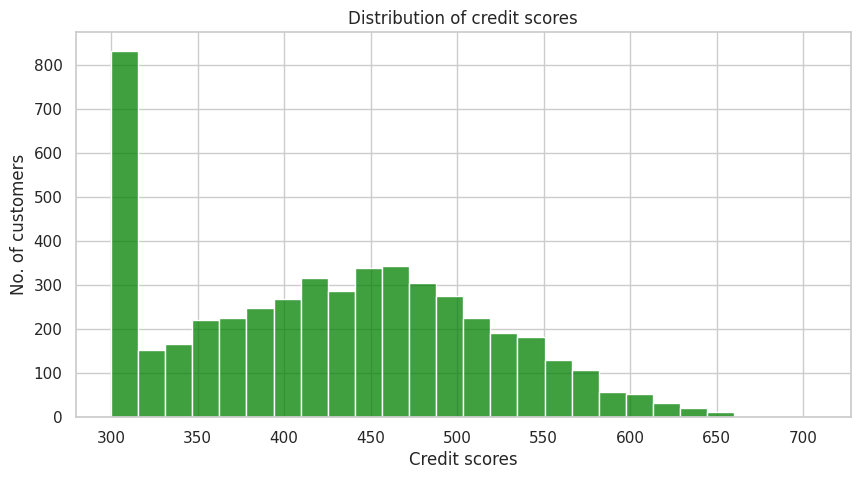

In [34]:
plt.figure(figsize=(10,5))
sns.histplot(df['Credit_Score'],color = 'green')
plt.title("Distribution of credit scores")
plt.xlabel('Credit scores')
plt.ylabel('No. of customers')

### Insights: Credit score distribution
Most scores lie between **400 and 500**, with a healthy bell curve shape.
Very low and very high scores are rare.



/tmp/ipython-input-35-2422021882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'Employment_Type', y = 'Credit_Score', palette = 'viridis')


([0, 1, 2, 3],
 [Text(0, 0, 'Full-Time'),
  Text(1, 0, 'Retired'),
  Text(2, 0, 'Part-Time'),
  Text(3, 0, 'Unemployed')])

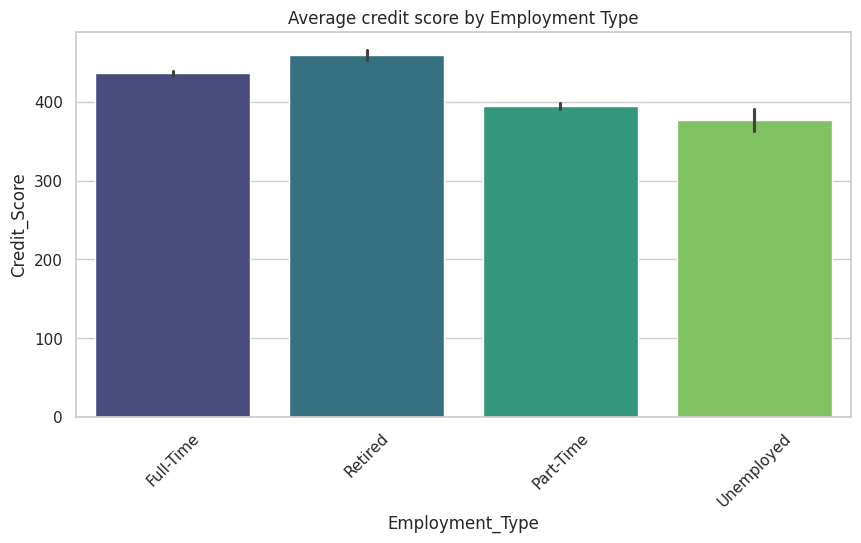

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(data = df, x = 'Employment_Type', y = 'Credit_Score', palette = 'viridis')
plt.title("Average credit score by Employment Type")
plt.xticks(rotation = 45)

###Insight: Employment type
Retired and Full-time workers show higher credit scores, while Unemployed and Part-time individuals typically score lower due to less financial stability.

Text(0, 0.5, 'Credit Score')

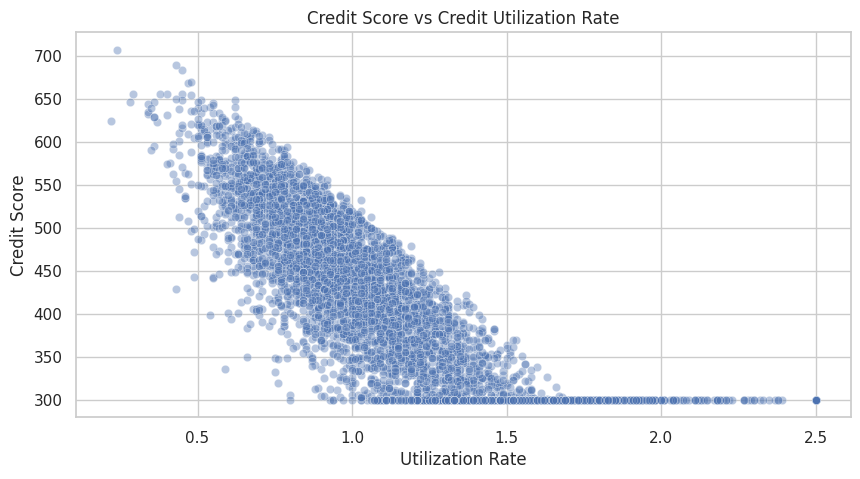

In [36]:
plt.figure(figsize=(10,5))
sns.scatterplot(data = df, x = 'Credit_Utilization_Rate', y = 'Credit_Score', alpha = 0.4)
plt.title("Credit Score vs Credit Utilization Rate")
plt.xlabel('Utilization Rate')
plt.ylabel('Credit Score')

###Insight: Utilization Rate
A clear **negative correlation** appears - higher credit utilization leads tomlower credit scores aligning with real world credit behaviour.

Text(0, 0.5, 'Avg Monthly Spend')

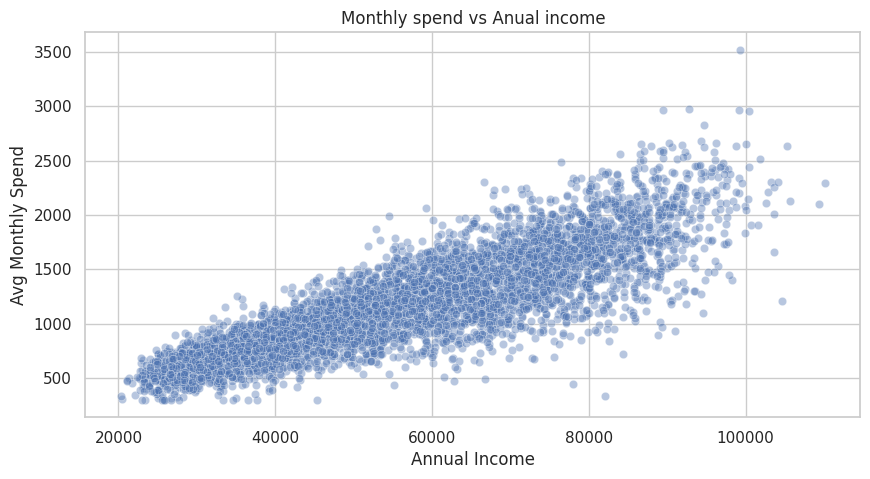

In [37]:
plt.figure(figsize=(10,5))
sns.scatterplot(data = df, x = 'Annual_Income', y = 'Avg_Monthly_Spend', alpha = 0.4)
plt.title("Monthly spend vs Anual income")
plt.xlabel('Annual Income')
plt.ylabel('Avg Monthly Spend')

###Insight: Income vs Spending
As income increases, average spend tends to increase., though not linearly. Spending habits vary even among high income users.

/tmp/ipython-input-38-2545992941.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'Education_Level', y = 'Credit_Score', palette = 'pastel')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Bachelor’s Degree'),
  Text(1, 0, 'Associate Degree'),
  Text(2, 0, 'Master’s Degree'),
  Text(3, 0, 'High School'),
  Text(4, 0, 'Doctorate')])

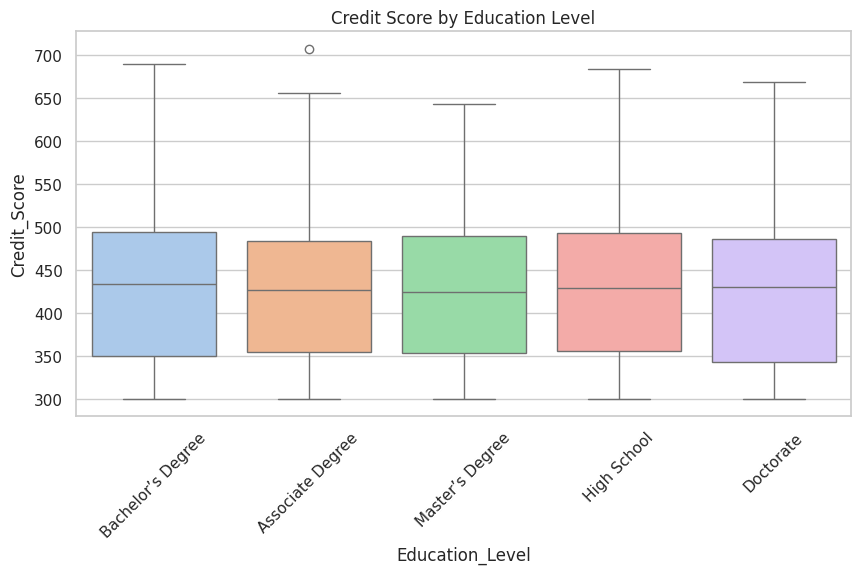

In [38]:
plt.figure(figsize=(10,5))
sns.boxplot(data = df, x = 'Education_Level', y = 'Credit_Score', palette = 'pastel')
plt.title("Credit Score by Education Level")
plt.xticks(rotation = 45)


###Insight: Education Level
Higher education levels show slightly better credit scores on average. The variation within each group suggests other factors also play a role.

Text(0.5, 1.0, 'Correlation Heatmap')

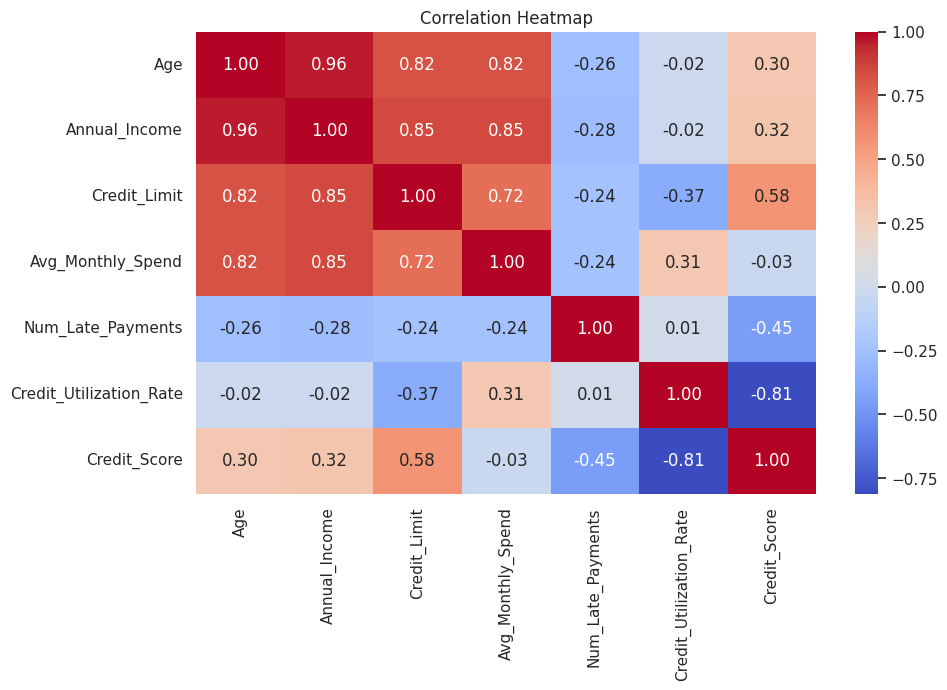

In [39]:
plt.figure(figsize=(10,6))
corr = df[['Age', 'Annual_Income', 'Credit_Limit', 'Avg_Monthly_Spend',
           'Num_Late_Payments', 'Credit_Utilization_Rate', 'Credit_Score']].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')

###Insight:Correlation Matrix
- `Credit_Score` has strong negative correlations with
`Credit_Utilization_Rate` and `Late_Payments`
- `Annual_Income`, `Credit_Limit` and `Spend` are positively correlated.

In [40]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
#Drop unused columns
df_model = df.drop(columns=['Customer_ID', 'Gender', 'State', 'Education_Level'])


In [42]:
#Encode Employment Type
df_model = pd.get_dummies(df_model, columns = ['Employment_Type'], drop_first = True)

In [43]:
# Define features and target
X = df_model.drop(columns = ['Credit_Score'])
y = df_model['Credit_Score']

In [44]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [45]:
# Feature scaling
scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

In [46]:
# Train the model
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [47]:
y_pred = model.predict(X_test_scaled)

In [48]:
# Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test,y_pred)

print(f"Mean absolute error: {mae: .2f}")
print(f"Root ean squared error: {rmse: .2f}")
print(f"R2 Score: {r2: .2f}")

Mean absolute error:  2.90
Root ean squared error:  5.15
R2 Score:  1.00


Text(0, 0.5, 'Predicted Credit Score')

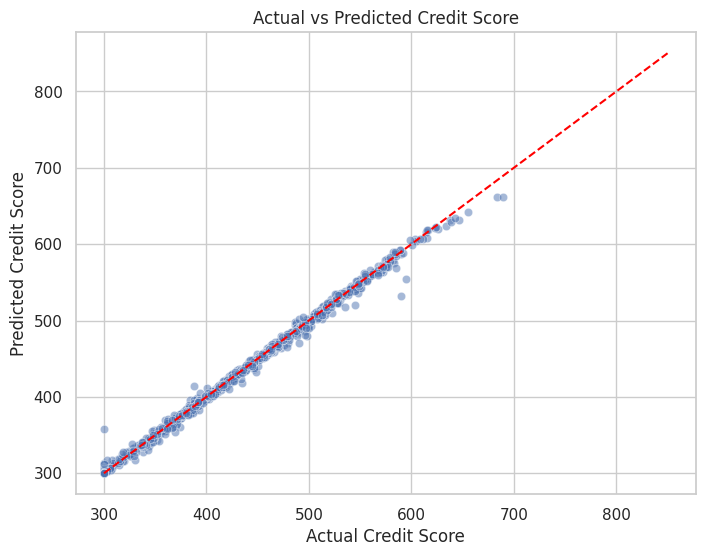

In [49]:
# Actual vs predicted
plt.figure(figsize = (8,6))
sns.scatterplot(x = y_test, y = y_pred, alpha = 0.5)
plt.plot([300, 850], [300, 850], color = 'red', linestyle = '--')
plt.title('Actual vs Predicted Credit Score')
plt.xlabel('Actual Credit Score')
plt.ylabel('Predicted Credit Score')

### Actual vs Predicted Insight
- The scatter plot shows most prediction falling near the diagonal line, indicating good model accuracy.
- A few outliners may represent unique customer behaviors not fully captured by our features.
- Overall, the model generalizes well and can estimate creditworthiness with reasonable confidence.

/tmp/ipython-input-50-17826606.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = feature_df, x = 'Importance', y = 'Feature', palette = 'viridis')


Text(0.5, 1.0, 'Feature Importance for Predicting Credit Score')

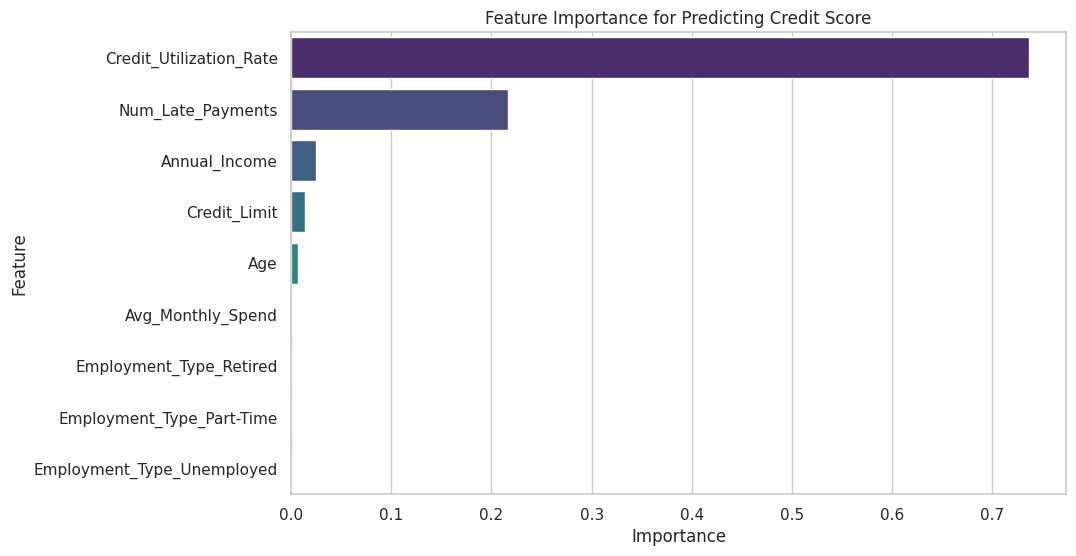

In [50]:
# Feature Importance
importances = model.feature_importances_
features = X.columns
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (10, 6))
sns.barplot(data = feature_df, x = 'Importance', y = 'Feature', palette = 'viridis')
plt.title('Feature Importance for Predicting Credit Score')

### Feature Importance Insights
- **Credit Utilization Rate** is the. ost important feature - reinforces the real-world importance of responsible credit use.
- **Number of late payments** is also a strong signal- capturing repayment behavior.
- **Annual Income** and **Monthly Spend** influence score indirectly by reflecting financial capacity.
- Employment type (e.g., Full-Time, Self-Employed) plays a subtle but valuable role in credit score prediction. These insights reflect industry patterns and help validate the model's realism.